In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/train.csv")
df.head()

,Id,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,186878,23.0,Male,44.0,18.0,0.0,19.0,Basic,Quarterly,846.18,18.0,0.0
1,414188,19.0,Male,41.0,29.0,1.0,26.0,Basic,Annual,149.04,10.0,1.0
2,419671,40.0,Male,48.0,11.0,3.0,19.0,Basic,Annual,266.00,9.0,1.0
3,428771,44.0,Female,58.0,21.0,2.0,27.0,Standard,Quarterly,662.00,16.0,1.0
4,302010,49.0,Male,24.0,29.0,9.0,9.0,Standard,Monthly,857.00,8.0,1.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404165 entries, 0 to 404164
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Id                 404165 non-null  int64  
 1   Age                404165 non-null  float64
 2   Gender             404165 non-null  object 
 3   Tenure             404165 non-null  float64
 4   Usage Frequency    404165 non-null  float64
 5   Support Calls      404165 non-null  float64
 6   Payment Delay      404165 non-null  float64
 7   Subscription Type  404165 non-null  object 
 8   Contract Length    404165 non-null  object 
 9   Total Spend        404165 non-null  float64
 10  Last Interaction   404165 non-null  float64
 11  Churn              404165 non-null  float64
dtypes: float64(8), int64(1), object(3)
memory usage: 37.0+ MB


In [3]:
df.describe()

,Id,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,404165.000000,404165.000000,404165.000000,404165.000000,404165.000000,404165.000000,404165.000000,404165.000000,404165.000000
mean,252486.016676,39.709388,31.346693,15.718976,3.830703,13.494808,620.278390,14.603890,0.554776
std,145807.585409,12.681057,17.231919,8.617287,3.134619,8.453428,245.179751,8.609196,0.496991
min,0.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,126139.000000,29.000000,16.000000,8.000000,1.000000,6.000000,446.670000,7.000000,0.000000
50%,252443.000000,40.000000,32.000000,16.000000,3.000000,13.000000,649.000000,14.000000,1.000000
75%,378709.000000,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,505206.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [4]:
print(f"Total null value: {df.isnull().sum().sum()}")

Total null value: 0


In [5]:
print("Total missing value for each columns:")
df.isnull().sum()

Total missing value for each columns:


Id                   0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [6]:
df = df.drop(["Id"], axis=1)
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,23.0,Male,44.0,18.0,0.0,19.0,Basic,Quarterly,846.18,18.0,0.0
1,19.0,Male,41.0,29.0,1.0,26.0,Basic,Annual,149.04,10.0,1.0
2,40.0,Male,48.0,11.0,3.0,19.0,Basic,Annual,266.00,9.0,1.0
3,44.0,Female,58.0,21.0,2.0,27.0,Standard,Quarterly,662.00,16.0,1.0
4,49.0,Male,24.0,29.0,9.0,9.0,Standard,Monthly,857.00,8.0,1.0


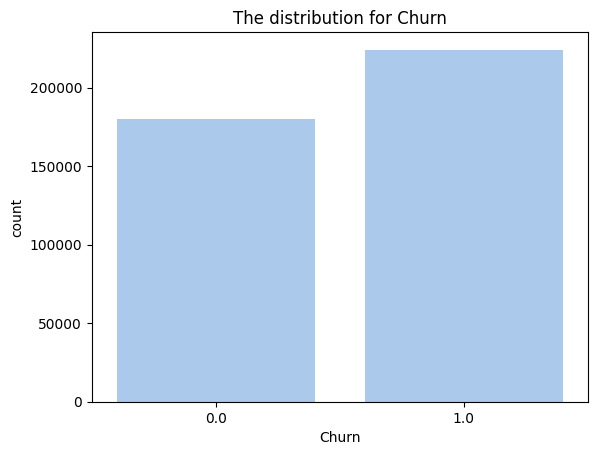

In [7]:
import seaborn as sns
from matplotlib import pyplot as plt
sns.set_palette("pastel")

sns.countplot(data=df, x="Churn")
plt.title("The distribution for Churn")
plt.show()

In [8]:
print("Churn count:")
df["Churn"].value_counts()

Churn count:


Churn
1.0    224221
0.0    179944
Name: count, dtype: int64

In [9]:
churn_ratios = df['Churn'].value_counts(normalize=True)

print(f"\nChurn (1.0): {churn_ratios[1.0] * 100:.2f}%")
print(f"No Churn (0.0): {churn_ratios[0.0] * 100:.2f}%")


Churn (1.0): 55.48%
No Churn (0.0): 44.52%


In [10]:
import numpy as np

numerical_features = [col for col in df.columns if df[col].dtype == np.float64 and col != "Churn"]
numerical_features

['Age',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Total Spend',
 'Last Interaction']

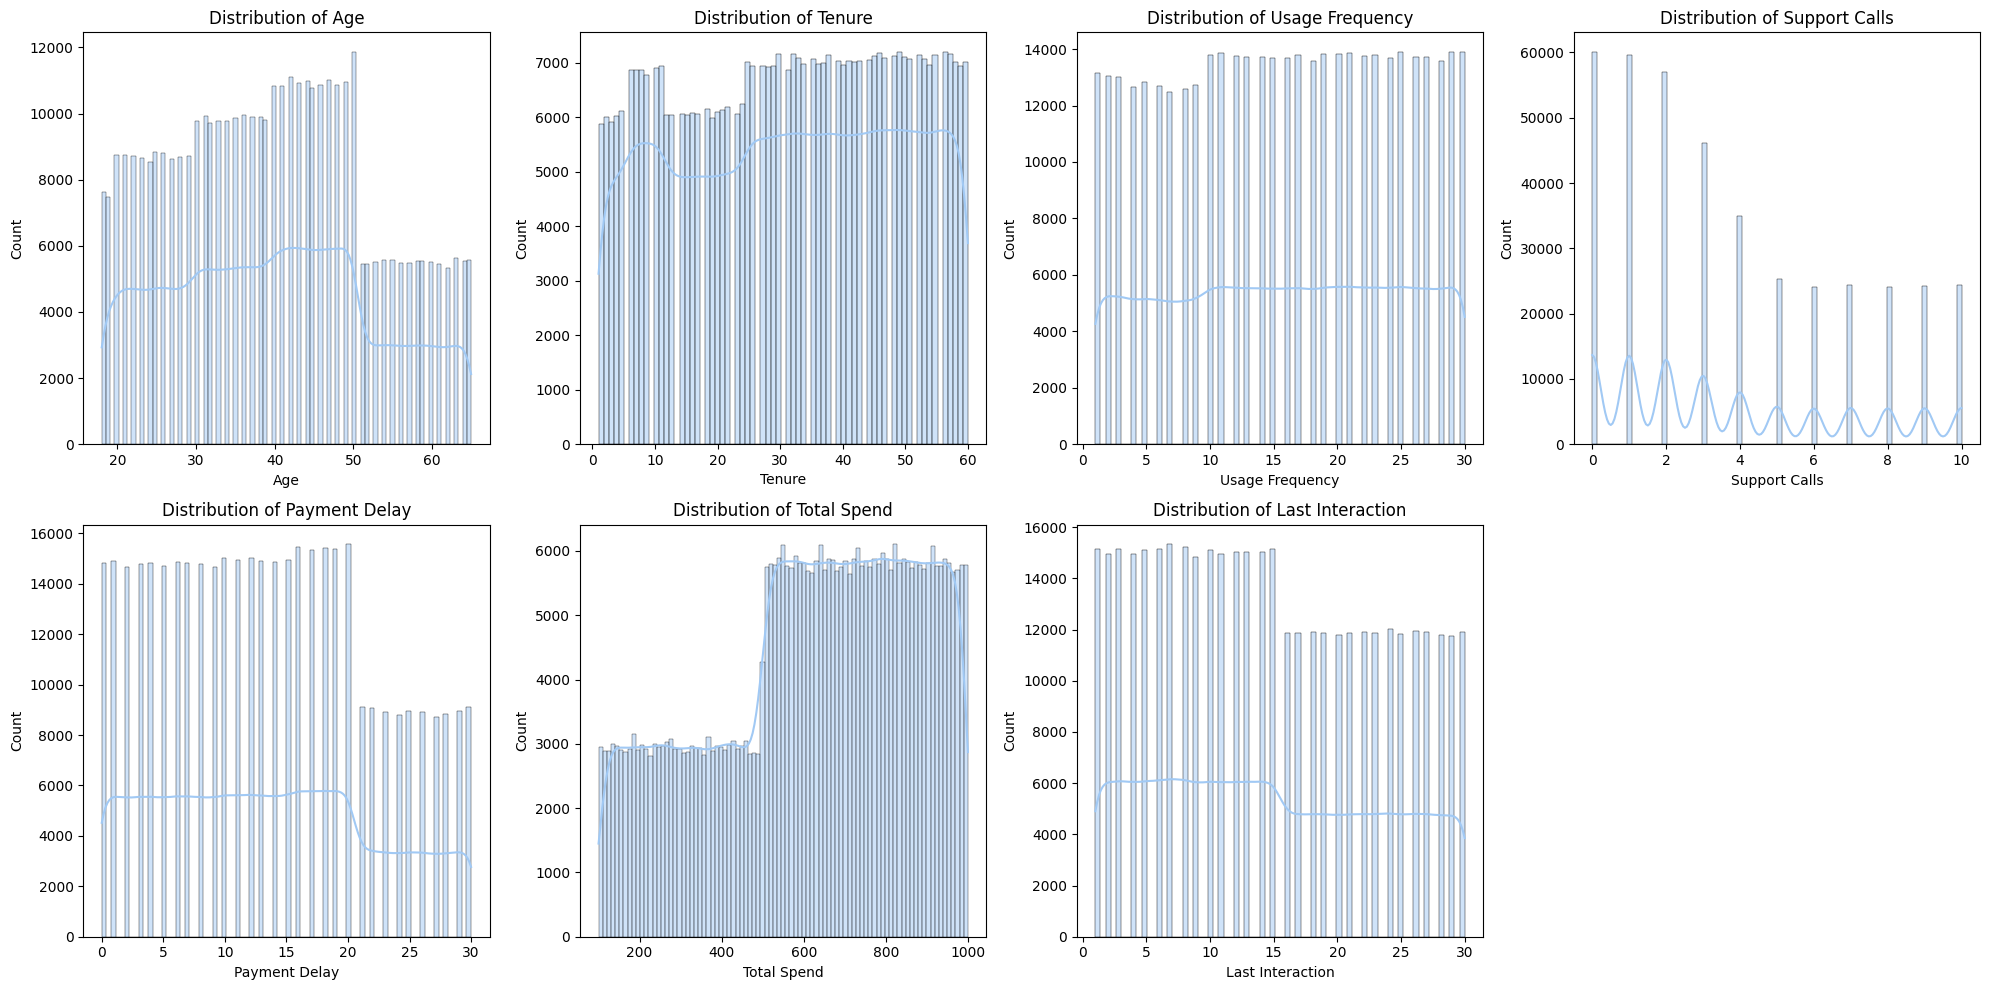

In [11]:

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes_list = axes.flatten()

for feature, ax in zip(numerical_features, axes_list):
    sns.histplot(data=df, x=feature, kde=True, ax=ax)
    ax.set_title(f'Distribution of {feature}')

axes_list[7].axis('off')
plt.tight_layout()
plt.show()

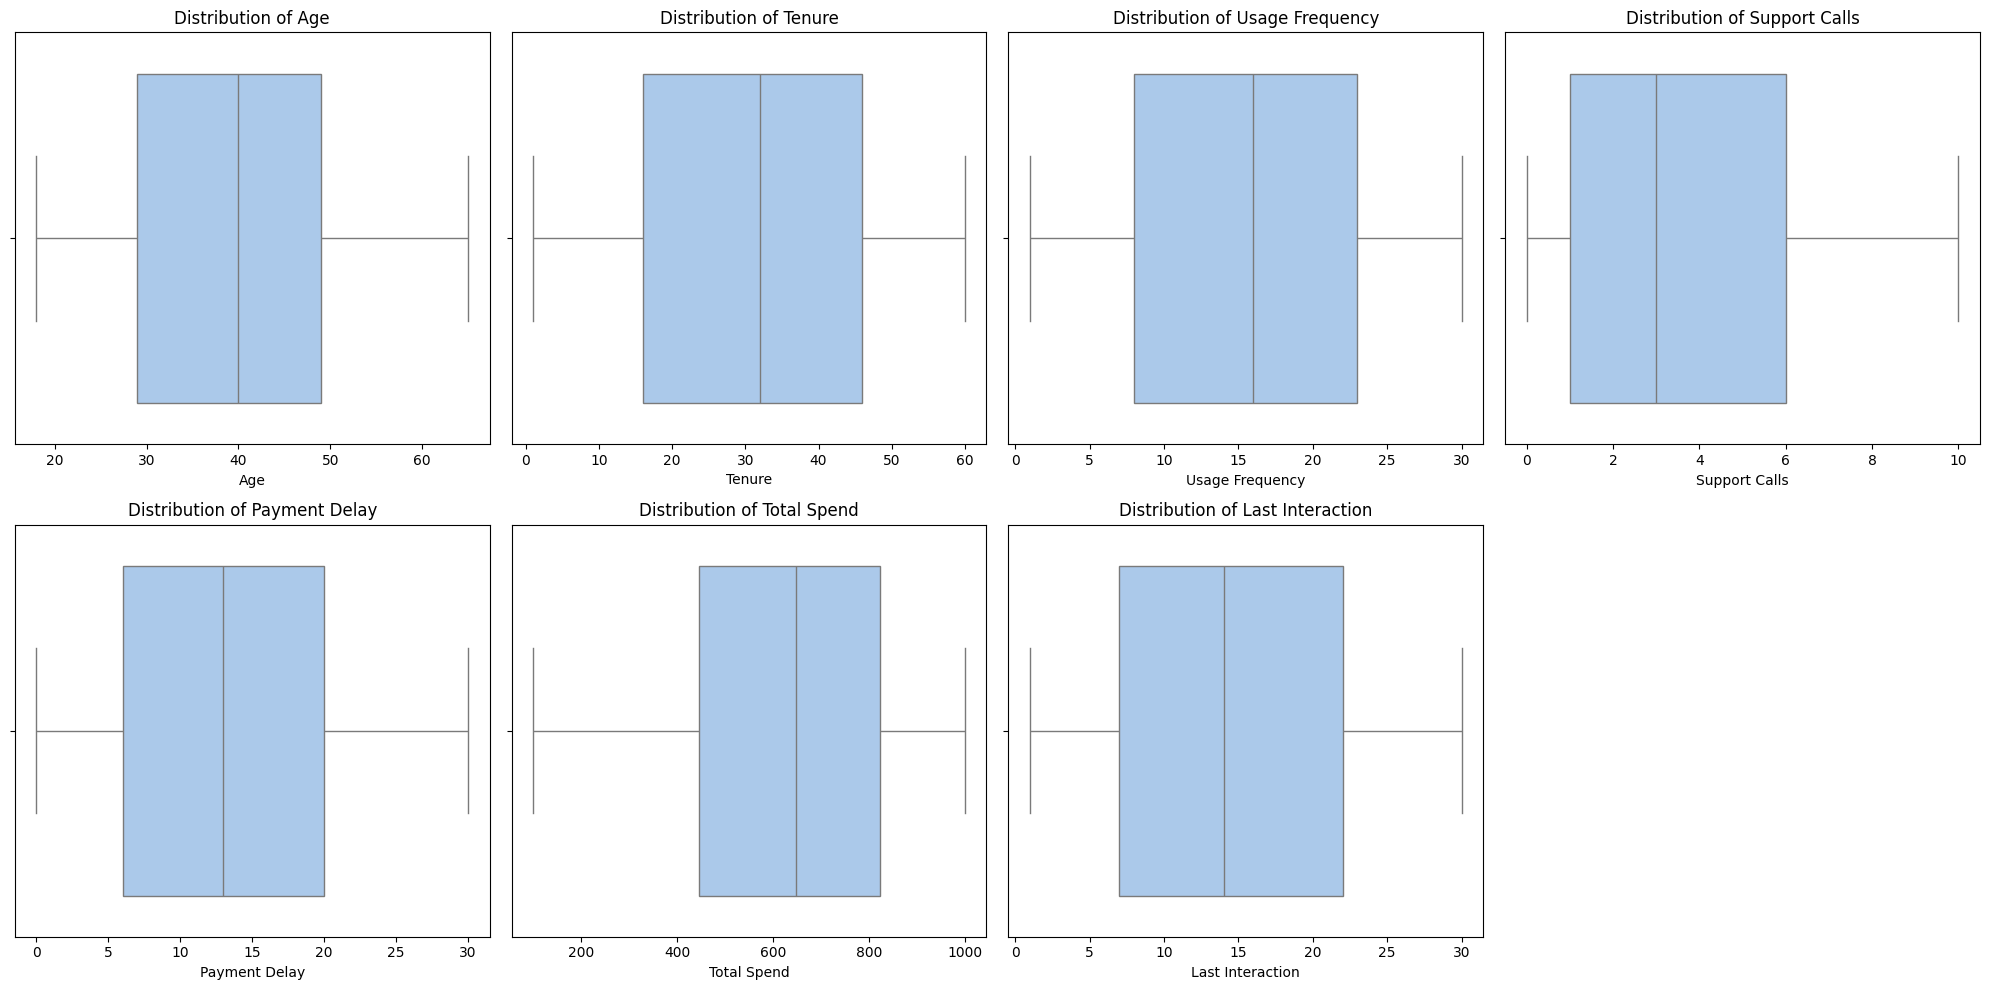

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes_list = axes.flatten()

for feature, ax in zip(numerical_features, axes_list):
    sns.boxplot(data=df, x=feature, ax=ax)
    ax.set_title(f'Distribution of {feature}')

axes_list[7].axis('off')
plt.tight_layout()
plt.show()

In [13]:
categorical_features = [col for col in df.columns if df[col].dtype == object]
categorical_features

['Gender', 'Subscription Type', 'Contract Length']

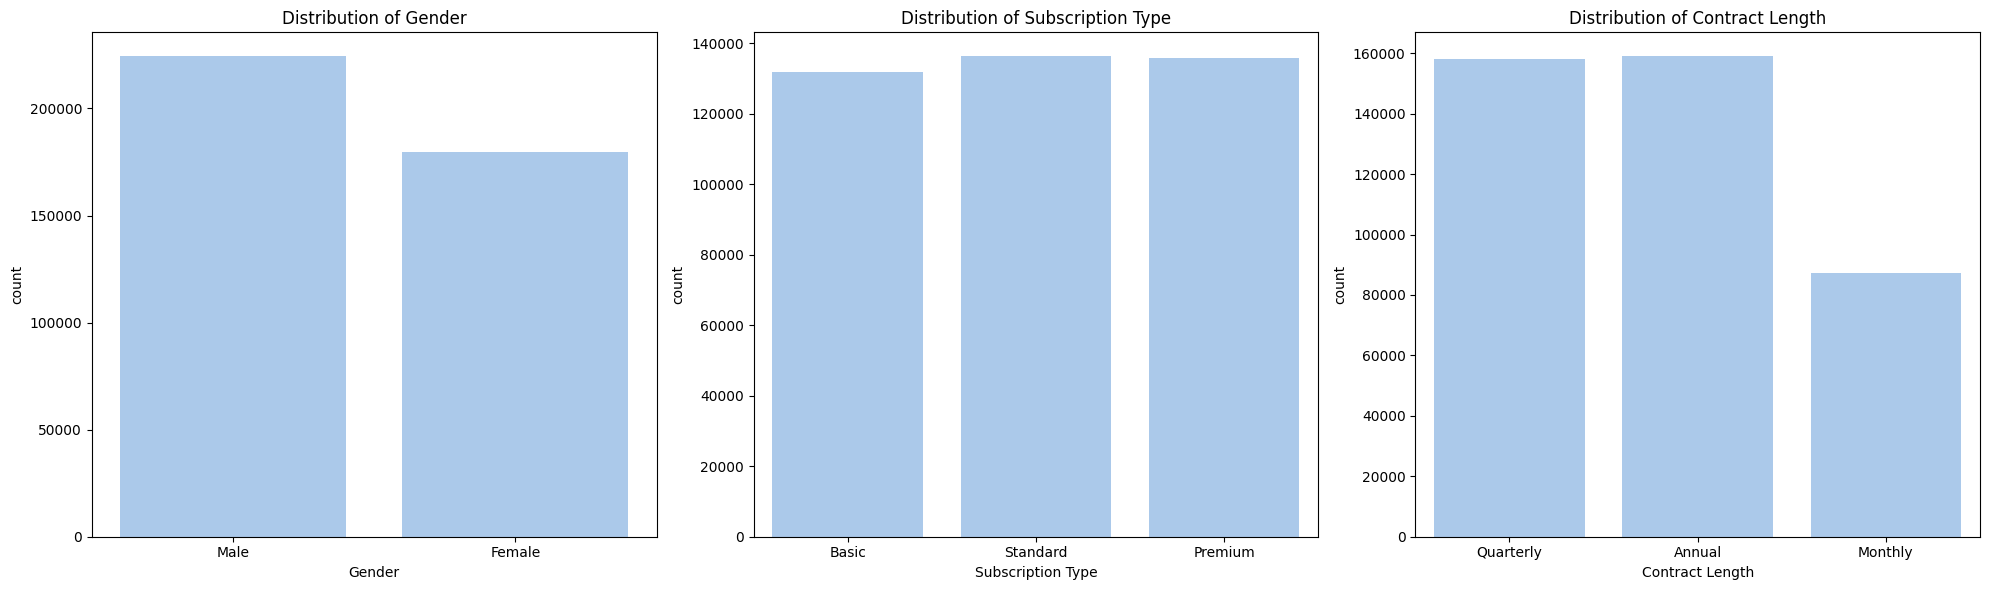

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))
axes_list = axes.flatten()

for feature, ax in zip(categorical_features, axes_list):
    sns.countplot(data=df, x=feature, ax=ax)
    ax.set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

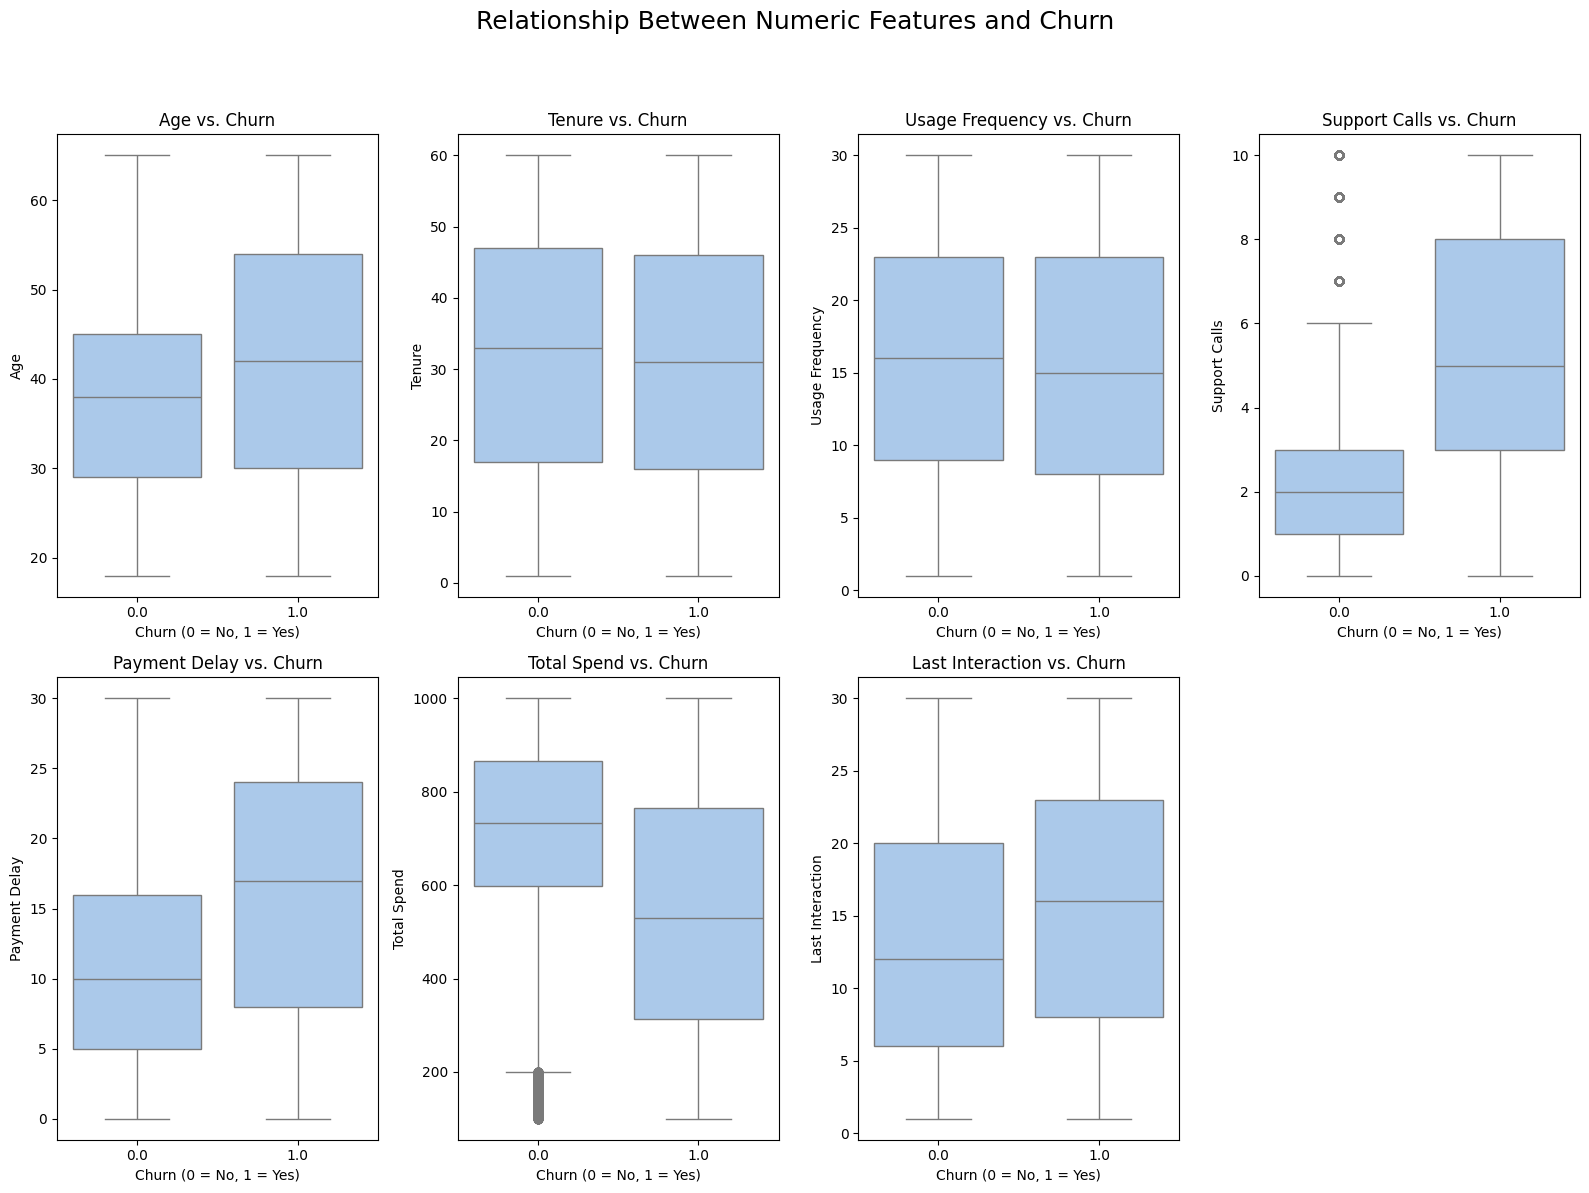

In [16]:
plt.figure(figsize=(16, 12))
plt.suptitle('Relationship Between Numeric Features and Churn', fontsize=18, y=1.02)

for i, col in enumerate(numerical_features):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(data=df, x='Churn', y=col)
    
    plt.title(f'{col} vs. Churn')
    plt.xlabel('Churn (0 = No, 1 = Yes)')
    plt.ylabel(col)

plt.tight_layout(rect=(0, 0.03, 1, 0.98))
plt.show()